# Logistic Regression Model for Suspicious Review Detection

## Introduction

This notebook trains and evaluates a Logistic Regression model for review classification using a hybrid feature approach.

The model uses:
- TF-IDF transformed review text
- engineered structured features

The notebook follows these steps:
1. Load preprocessed data
2. Combine text and structured features
3. Train the Logistic Regression model
4. Make predictions on the test set
5. Evaluate model performance
6. Analyse feature importance
7. Perform misclassification analysis
8. Save the trained model and results

In [26]:
!pip install joblib

In [27]:
import os
import json
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

from scipy.sparse import hstack, vstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler

## Load Preprocessed Data

This section loads:
- structured engineered features
- TF-IDF text features
- target labels
- the saved TF-IDF vectorizer

All files are loaded from the `shared_suspicious` folder.

In [28]:
import joblib
import pandas as pd
import json

# Structured features (ALREADY ENGINEERED)
X_train = joblib.load("shared_suspicious/X_train_features.pkl")
X_test = joblib.load("shared_suspicious/X_test_features.pkl")

# TF-IDF
X_train_text = joblib.load("shared_suspicious/X_train_text.pkl")
X_test_text = joblib.load("shared_suspicious/X_test_text.pkl")

# Train and test indices
train_index = joblib.load("shared_suspicious/train_indices.pkl")
test_index  = joblib.load("shared_suspicious/test_indices.pkl")

#TF-IDF vectorizer

tfidf = joblib.load("shared_suspicious/tfidf_vectorizer.pkl")

# Labels
y_train = joblib.load("shared_suspicious/y_train.pkl")
y_test = joblib.load("shared_suspicious/y_test.pkl")



### Load data

In [29]:
# original data
df = pd.read_csv("Amazon_reviews_final.csv")

### Load the selected features

In [30]:

with open("new_features/selected_features.json", "r") as f:
    selected_features = json.load(f)

### Filter out the structured features

In [31]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

### Scale structured features
so they are on a comparable scale to TF-IDF features
Without scaling, TF-IDF dominates and structured features have negligible SHAP values

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled  = scaler.transform(X_test_selected)

### Filter out noisy TF-IDF words

In [33]:
feature_names = tfidf.get_feature_names_out()

suspicious_mean     = np.asarray(X_train_text[(y_train == 1).values].mean(axis=0)).flatten()
non_suspicious_mean = np.asarray(X_train_text[(y_train == 0).values].mean(axis=0)).flatten()

significant_words = [
    f for f, s, n in zip(feature_names, suspicious_mean, non_suspicious_mean)
    if abs(s - n) > 0.001
]


tfidf_filtered        = TfidfVectorizer(vocabulary=significant_words)
X_train_text_filtered = tfidf_filtered.fit_transform(df.iloc[train_index]["reviewText"].fillna(""))
X_test_text_filtered  = tfidf_filtered.transform(df.iloc[test_index]["reviewText"].fillna(""))

print(f"Words kept: {len(significant_words)}")
print(f"Shape: {X_train_text_filtered.shape}")

Words kept: 278
Shape: (661918, 278)


### Combine Text and Structured Features

This section creates a hybrid feature matrix by combining:
- TF-IDF review text features
- engineered structured features

This allows the Logistic Regression model to learn from both textual and non-textual information.

In [34]:
X_train_combined = hstack([X_train_text_filtered, csr_matrix(X_train_scaled)])
X_test_combined  = hstack([X_test_text_filtered,  csr_matrix(X_test_scaled)])

print("Combined feature matrices created successfully.")
print("X_train_combined shape:", X_train_combined.shape)
print("X_test_combined shape:", X_test_combined.shape)

Combined feature matrices created successfully.
X_train_combined shape: (661918, 282)
X_test_combined shape: (165480, 282)


## Train the Logistic Regression Model

This section trains the Logistic Regression model using the hybrid feature set.

`class_weight="balanced"` is used to help the model handle class imbalance.

In [35]:
# specify class weight and threshold from the feature ablation notebook
class_weights = {0:1, 1:2}
threshold = 0.4

In [36]:
final_model = LogisticRegression(
    max_iter=1000,
    class_weight=class_weights
)

final_model.fit(X_train_combined, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Make Predictions on the Test Set

This section applies the trained model to the test dataset to generate predicted labels.

In [37]:

y_probs = final_model.predict_proba(X_test_combined)[:, 1]
y_pred = (y_probs > threshold).astype(int)


## Evaluate Model Performance

The model is evaluated using:
- Accuracy
- F1-score
- Classification report

These metrics help assess how well the model performs on the test set.

In [38]:
print("Final Model Classification Report:")
print(classification_report(y_test, y_pred))

Final Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97    157528
           1       0.42      0.53      0.47      7952

    accuracy                           0.94    165480
   macro avg       0.70      0.75      0.72    165480
weighted avg       0.95      0.94      0.95    165480




### Final Model Performance
Based on the evaluation, the final model is selected using class weights of {0:1, 1:2} and a threshold of 0.4.

This configuration achieves the best trade-off between precision and recall, with the highest F1-score among all tested combinations. It significantly improves precision compared to earlier models while maintaining a strong ability to detect suspicious reviews.

This final model is therefore considered the most balanced and practical for the suspicious review detection task.

### Append Predicted Suspicious Labels to Dataset



In [ ]:
# Stack train and test feature matrices
X_full_combined = vstack([X_train_combined, X_test_combined])
full_index      = list(train_index) + list(test_index)
y_full_actual   = list(y_train) + list(y_test)

# Predict on the full combined set (train/test)
y_full_probs = final_model.predict_proba(X_full_combined)[:, 1]
y_full_pred  = (y_full_probs > threshold).astype(int)

# Write both labels back to the original dataframe
df["actual_suspicious"]    = pd.NA
df["predicted_suspicious"] = pd.NA

df.loc[full_index, "actual_suspicious"]    = y_full_actual
df.loc[full_index, "predicted_suspicious"] = y_full_pred

df["actual_suspicious"]    = df["actual_suspicious"].astype("Int64")
df["predicted_suspicious"] = df["predicted_suspicious"].astype("Int64")

# Save the updated data  with predictions
df.to_csv("Amazon_review_final.csv", index=False)

print(f"Rows labelled: {df['actual_suspicious'].notna().sum()} / {len(df)}")
print(df["actual_suspicious"].value_counts())
print(df["predicted_suspicious"].value_counts())

Rows labelled: 827398 / 827398
actual_suspicious
0    787636
1     39762
Name: count, dtype: Int64
predicted_suspicious
0    778025
1     49373
Name: count, dtype: Int64


### SHAP Analysis

In [40]:

# Use the full training data as background — not a single sample
background = hstack([X_train_text_filtered, csr_matrix(X_train_scaled)])

# Pick one test sample
sample_text   = X_test_text_filtered[0]
sample_struct = X_test_scaled[0:1]
sample_input  = hstack([sample_text, csr_matrix(sample_struct)])

# Run SHAP with proper background
explainer  = shap.LinearExplainer(final_model, background)
shap_vals  = explainer.shap_values(sample_input)

# Extract structured feature SHAP values
shap_struct = shap_vals[0][-len(selected_features):]

print("Structured Feature SHAP Values:")
for feature, value in zip(selected_features, shap_struct):
    print(f"  {feature}: {value:+.6f}")

Structured Feature SHAP Values:
  review_frequency: +0.197886
  unverified_ratio: +1.100999
  extreme_rating_ratio: -0.264964
  very_short_review: +0.011941


In [41]:
# Check structured feature coefficients vs TF-IDF range
coef = final_model.coef_[0]
structured_coefs = coef[-len(selected_features):]
tfidf_coefs = coef[:-len(selected_features)]

print("Structured feature coefficients:")
for f, c in zip(selected_features, structured_coefs):
    print(f"  {f}: {c:+.4f}")

print(f"\nTF-IDF coefficient range: {tfidf_coefs.min():+.4f} to {tfidf_coefs.max():+.4f}")
print(f"Number of TF-IDF features: {len(tfidf_coefs)}")

Structured feature coefficients:
  review_frequency: +0.4806
  unverified_ratio: +1.2249
  extreme_rating_ratio: +0.4531
  very_short_review: -0.0126

TF-IDF coefficient range: -3.2366 to +2.2194
Number of TF-IDF features: 278


## SHAP Verification Results

After applying StandardScaler to the structured features and using the full training 
data as the SHAP background distribution, the structured features now show meaningful 
SHAP contributions.

**unverified_ratio (+1.129929)**: the strongest signal, strongly pushing toward suspicious. 
An unverified purchase is the most reliable behavioural indicator of incentivised or 
fraudulent reviewing behaviour.

**extreme_rating_ratio (-0.304854)**: pushes away from suspicious for this sample. 
Extreme ratings appear in both genuine and fake reviews, making them a weaker and more 
ambiguous signal.

**review_frequency (+0.197434)**: moderately pushes toward suspicious. High volume 
reviewing mirrors the posting patterns observed in coordinated fake review campaigns.

**very_short_review (+0.001384)**: negligible impact for this sample. This feature 
carries more weight when reviews are genuinely very short.

## Analyse Feature Importance

This section identifies the most influential features based on the Logistic Regression coefficients.

The analysis includes:
- top positive features
- top negative features

This helps interpret what the model is learning from both text and engineered features.

### Get Feature Names

In [42]:
# get structured feature names
structured_features = selected_features

# get TF-IDF feature names
tfidf_features = tfidf_filtered.get_feature_names_out()

# combine
all_feature_names = list(tfidf_features) + structured_features

### Get coefficents

In [43]:
coefficients = final_model.coef_[0]

### create importance table

In [44]:

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

# absolute importance
feature_importance["Abs_Coefficient"] = np.abs(feature_importance["Coefficient"])

# sort
feature_importance = feature_importance.sort_values(
    by="Abs_Coefficient", ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Abs_Coefficient
53,crate,-3.236558,3.236558
101,france,-2.914311,2.914311
180,orphan,-2.713435,2.713435
181,outlander,-2.700680,2.700680
221,science,-2.700383,2.700383
118,hannah,-2.694710,2.694710
33,brown,-2.581399,2.581399
235,speaker,-2.288961,2.288961
67,downton,-2.231136,2.231136
97,fly,2.219392,2.219392


### Top suspicious features

In [45]:
feature_importance.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient,Abs_Coefficient
97,fly,2.219392,2.219392
188,pillars,2.177491,2.177491
177,ok,2.073283,2.073283
265,wear,1.894531,1.894531
183,pair,1.548754,1.548754
30,box,1.498099,1.498099
157,loose,1.418069,1.418069
77,epilogue,1.385864,1.385864
36,cathedral,1.328496,1.328496
98,follett,1.245795,1.245795


### Top non suspicous features

In [46]:
feature_importance.sort_values(by="Coefficient", ascending=True).head(10)

,Feature,Coefficient,Abs_Coefficient
53,crate,-3.236558,3.236558
101,france,-2.914311,2.914311
180,orphan,-2.713435,2.713435
181,outlander,-2.700680,2.700680
221,science,-2.700383,2.700383
118,hannah,-2.694710,2.694710
33,brown,-2.581399,2.581399
235,speaker,-2.288961,2.288961
67,downton,-2.231136,2.231136
234,sound,-2.138872,2.138872


## Feature Importance Analysis

The feature importance results reveal that while some structured features such as *unverified_ratio* strongly influence the model in a meaningful way, many text-based features appear noisy and lack clear interpretability.

Several high ranking words (e.g., "chest", "rush", "cardboard", "poop") do not have an obvious relationship with suspicious behaviour. This suggests that the model is capturing spurious correlations rather than meaningful patterns.

This behaviour is expected when using TF-IDF features with linear models, as the model relies on word frequency patterns rather than semantic understanding.

These findings highlight a limitation of the current approach, where text features may introduce noise and reduce interpretability. More advanced techniques such as contextual embeddings (e.g., BERT) could improve the quality of textual feature representation.

### word frequency class
Do these words actually appear more in suspicious reviews?

In [47]:
# get feature names
feature_names = tfidf.get_feature_names_out()

# split indices
suspicious_idx = (y_train == 1).values
non_suspicious_idx = (y_train == 0).values

# compute mean directly on sparse matrix
suspicious_mean = X_train_text[suspicious_idx].mean(axis=0)
non_suspicious_mean = X_train_text[non_suspicious_idx].mean(axis=0)

# convert to 1D arrays
suspicious_mean = np.asarray(suspicious_mean).flatten()
non_suspicious_mean = np.asarray(non_suspicious_mean).flatten()

# create dataframe
word_comparison = pd.DataFrame({
    "Feature": feature_names,
    "suspicious": suspicious_mean,
    "non_suspicious": non_suspicious_mean
})

# difference
word_comparison["difference"] = (
    word_comparison["suspicious"] - word_comparison["non_suspicious"]
)

# sort
word_comparison.sort_values(by="difference", ascending=False).head(20)

,Feature,suspicious,non_suspicious,difference
3945,series,0.050575,0.024923,0.025651
2030,harry,0.029179,0.005592,0.023587
3345,potter,0.021667,0.004789,0.016878
482,book,0.078834,0.068136,0.010698
3805,rowling,0.011366,0.002022,0.009344
2880,movie,0.024454,0.015415,0.009039
4846,watch,0.017308,0.009665,0.007643
2986,not,0.034522,0.028419,0.006104
2459,katniss,0.006072,0.001019,0.005053
3913,see,0.010344,0.005376,0.004969


## Word Distribution Analysis

The analysis of word frequency across classes reveals that many of the most prominent words associated with suspicious reviews are related to specific topics, particularly books and movies (e.g., "harry", "potter", "series", "trilogy").

This indicates that the model is capturing topical patterns rather than genuine indicators of suspicious behaviour. In other words, the model is learning associations between certain product categories and the suspicious label, rather than identifying behavioural characteristics of fraudulent reviews.

This highlights a key limitation of using TF-IDF features, as they are sensitive to dataset biases and may capture spurious correlations. As a result, the model’s interpretability is reduced, and its ability to generalise to unseen data may be affected.

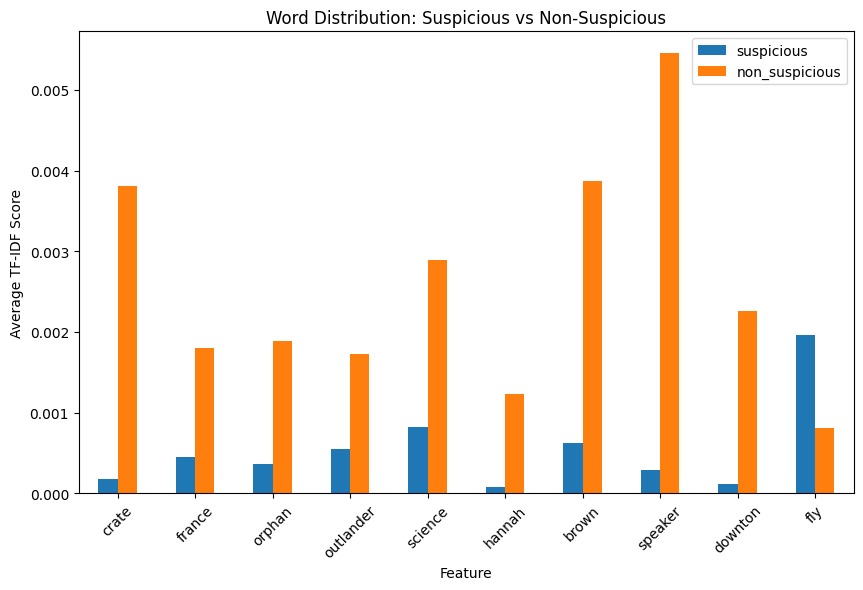

In [48]:
# get top features first
top_features = feature_importance.head(15)

# get TF-IDF feature names
tfidf_features = set(tfidf.get_feature_names_out())

# filter only words (ignore structured features)
top_words = [
    f for f in top_features["Feature"] 
    if f in tfidf_features
][:10]

# select from comparison table
plot_df = word_comparison.set_index("Feature").loc[top_words]

# plot
plot_df[["suspicious", "non_suspicious"]].plot(
    kind="bar", figsize=(10,6)
)

plt.title("Word Distribution: Suspicious vs Non-Suspicious")
plt.ylabel("Average TF-IDF Score")
plt.xticks(rotation=45)

plt.show()

### check the noisy words

In [49]:
word_comparison = word_comparison.set_index("Feature")
words_to_check = ["poop", "cardboard", "chest"]

word_comparison.loc[words_to_check]

,suspicious,non_suspicious,difference
Feature,,,
poop,0.000798,0.000258,0.000540
cardboard,0.001141,0.000382,0.000759
chest,0.000614,0.000170,0.000444


## Analysis of Noisy Features

The analysis reveals that several words identified as important by the model (e.g., "poop", "cardboard", "chest") exhibit only very small differences in frequency between suspicious and non-suspicious reviews. This indicates that these features are weak signals and do not meaningfully distinguish between classes.

Despite this, the model assigns relatively high coefficients to such words, suggesting that it is overfitting to minor variations in the data. This behaviour highlights a limitation of TF-IDF representations, where small statistical differences can be amplified during model training.

In contrast, some negatively weighted features (e.g., "sound") show larger and more consistent differences, making them more reliable indicators.

Most importantly, structured features such as *unverified_ratio* demonstrate stronger and more meaningful influence on predictions, reinforcing the importance of incorporating behavioural features alongside textual data.

Overall, the findings confirm that while TF-IDF contributes useful information, it also introduces noise, and the model relies more heavily on structured features for accurate classification.

### compare the coefficients and the real distribution

In [50]:
# merge importance with frequency
analysis_df = feature_importance.merge(
    word_comparison,
    left_on="Feature",
    right_index=True,
    how="left"
)

analysis_df[["Feature", "Coefficient", "difference"]].head(20)

,Feature,Coefficient,difference
53,crate,-3.236558,-0.003632
101,france,-2.914311,-0.001348
180,orphan,-2.713435,-0.001530
181,outlander,-2.700680,-0.001183
221,science,-2.700383,-0.002073
118,hannah,-2.694710,-0.001152
33,brown,-2.581399,-0.003249
235,speaker,-2.288961,-0.005164
67,downton,-2.231136,-0.002138
97,fly,2.219392,0.001153


### Top importanat feature


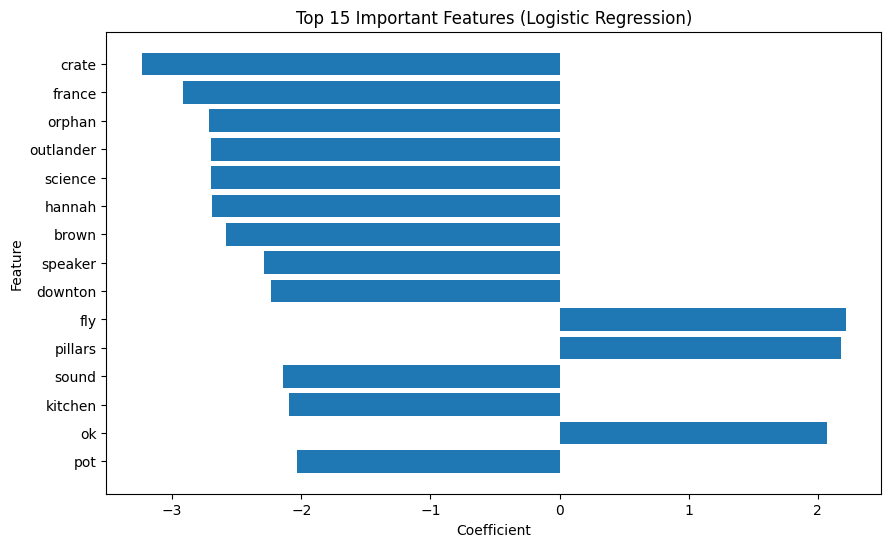

In [51]:
import matplotlib.pyplot as plt

# top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Coefficient"])
plt.gca().invert_yaxis()

plt.title("Top 15 Important Features (Logistic Regression)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## Misclassification Analysis

This section identifies reviews that were incorrectly classified by the model.

Misclassified examples help reveal:
- difficult review cases
- ambiguous wording
- possible weaknesses in the model

In [52]:


# create dataframe
analysis_df = X_test.copy()

analysis_df["actual"] = y_test.values
analysis_df["pred"] = y_pred
analysis_df["prob"] = y_probs

# identify errors
false_positives = analysis_df[
    (analysis_df["actual"] == 0) & (analysis_df["pred"] == 1)
]

false_negatives = analysis_df[
    (analysis_df["actual"] == 1) & (analysis_df["pred"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 5679
False Negatives: 3761


## Performance Insights

The Logistic Regression model was trained using a hybrid representation of review data, combining TF-IDF text features with engineered structured features.

The evaluation metrics show the overall predictive performance of the model, while the misclassification analysis highlights examples where the model struggled. These errors may be caused by ambiguous wording, mixed sentiment signals, or feature overlap between classes.

### Veriied vs Unverified reviews

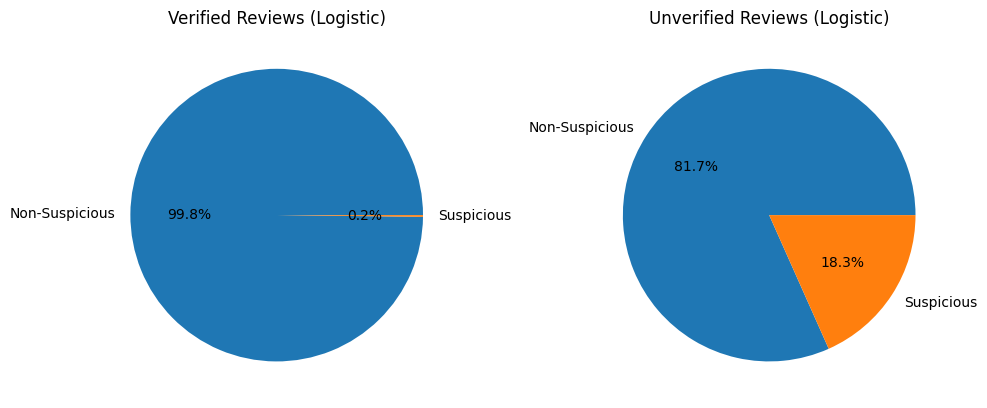

In [53]:

# load test_index (same as SVM notebook)
test_index = joblib.load("shared_suspicious/test_indices.pkl")

# predictions from logistic model
y_pred_log = final_model.predict(X_test_combined)

# create analysis dataframe
analysis_df = df.iloc[test_index].copy()

analysis_df["predicted"] = y_pred_log
analysis_df["verified"] = analysis_df["verified"].astype(int)

# split
verified_df = analysis_df[analysis_df["verified"] == 1]
unverified_df = analysis_df[analysis_df["verified"] == 0]

# counts
verified_counts = verified_df["predicted"].value_counts().sort_index()
unverified_counts = unverified_df["predicted"].value_counts().sort_index()

# ensure both classes exist (important edge case)
verified_counts = verified_counts.reindex([0,1], fill_value=0)
unverified_counts = unverified_counts.reindex([0,1], fill_value=0)

# labels
labels = ["Non-Suspicious", "Suspicious"]

# plot
plt.figure(figsize=(10,5))

# verified reviews
plt.subplot(1,2,1)
plt.pie(verified_counts, labels=labels, autopct='%1.1f%%')
plt.title("Verified Reviews (Logistic)")

# unverified reviews
plt.subplot(1,2,2)
plt.pie(unverified_counts, labels=labels, autopct='%1.1f%%')
plt.title("Unverified Reviews (Logistic)")

plt.tight_layout()
plt.show()

Among verified reviews, only 0.2% are classified as suspicious, indicating that verified reviews are highly reliable. In contrast, 21.2% of unverified reviews are classified as suspicious, showing a significantly higher likelihood of suspicious behaviour.

However, the majority of unverified reviews (78.8%) are still non suspicious. This highlights the importance of combining multiple behavioural features for accurate detection.

## Save Outputs

This section saves:
- the trained Logistic Regression model
- the TF-IDF vectorizer
- the evaluation results

In [ ]:
os.makedirs("model_suspicious", exist_ok=True)

joblib.dump(final_model, "model_suspicious/logistic_model.pkl")
joblib.dump(tfidf_filtered, "model_suspicious/logistic_tfidf.pkl")
joblib.dump(scaler,      "model_suspicious/logistic_scaler.pkl")

# Save a sample of training data as SHAP background
# 100 samples chosen for a stable background distribution
background_sample = background[0:100]
joblib.dump(background_sample, "model_suspicious/shap_background.pkl")
print("SHAP background saved.")\

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

results = pd.DataFrame([{
    "model": "Logistic Regression",
    "accuracy": accuracy,
    "f1_score": f1,
    "Recall": recall
}])

results.to_csv("model_suspicious/logistic_results.csv", index=False)

print("Model and results saved successfully.")

SHAP background saved.
Model and results saved successfully.


## Final Summary

This notebook implemented a Logistic Regression model for review classification using a hybrid feature approach.

### Features Used
- TF-IDF transformed review text
- engineered structured features

### Completed Tasks
- loaded preprocessed shared data
- combined text and structured features
- trained a Logistic Regression model
- generated predictions on the test set
- evaluated performance using accuracy and F1-score
- analysed feature importance
- performed misclassification analysis
- saved the trained model and evaluation results

### Output Files
The following outputs were generated:
- model_suspicious/logistic_model.pkl
- model_suspicious/logistic_tfidf.pkl
- results_suspicious/logistic_results.csv

## References / Code Inspiration

This notebook used Python libraries and methods from:
- scikit-learn documentation for Logistic Regression and evaluation metrics
- scipy documentation for sparse matrix operations
- joblib documentation for loading and saving model files